In [1]:
# import all modules

# import PyPlot from matplotlib library as plt
import matplotlib.pyplot as plt
# import pandas dataframe as pd
import pandas as pd
# import linear regression from sklearn library from linear_model subdirectory
from sklearn.linear_model import LinearRegression
# import decision tree regressor from sklearn library from tree subdirectory
from sklearn.tree import DecisionTreeRegressor
# import train_test_split module for split the data for test and train data from sklearn library from tree subdirectory from model_selection subdirectory
from sklearn.model_selection import train_test_split
# import metrics as met from sklearn library from metrics subdirectory
import sklearn.metrics as met

In [2]:
# Read da
# Var File in SPSS modeler

# read data from CSV file by pandas and save it to a pandas dataframe
raw_data = pd.read_csv("../data/GOODS1n/GOODS1n")

In [3]:
#Print dataframe of File
#Table Node in SPSS

# print raw data pandas dataframe 
print(raw_data)

          Class    Cost  Promotion  Before   After
0    Confection   23.99       1467  114957  122762
1         Drink   79.29       1745  123378  137097
2        Luxury   81.99       1426  135246  141172
3    Confection   74.18       1098  231389  244456
4    Confection   90.09       1968  235648  261940
..          ...     ...        ...     ...     ...
195      Luxury   87.95       1206  208121  221053
196      Luxury   95.45       1678  224351  238264
197      Luxury   69.04       1926  264383  281239
198       Drink  104.56       1530  140021  157411
199  Confection   10.88       1162  206186  217102

[200 rows x 5 columns]


In [4]:
# add increase value
# = Derive Node in SPSS

# copy the raw data dataframe for adding the increase value
data_with_increase = raw_data.copy()
# array with increase values
increase_array = []
# for cycle runs every index of raw data dataframe
for index in range(0, len(data_with_increase["Before"])):
    # calculate the increase value
    increase_array.append((data_with_increase["After"][index] - data_with_increase["Before"][index]) / data_with_increase["After"][index] * 100)
# adds increase value to the raw data dataframe
data_with_increase.loc[:, "Increase"] = increase_array

In [5]:
#Print dataframe of File with Increase
#Table Node in SPSS

# print raw data with increase value
print(data_with_increase)

          Class    Cost  Promotion  Before   After   Increase
0    Confection   23.99       1467  114957  122762   6.357831
1         Drink   79.29       1745  123378  137097  10.006784
2        Luxury   81.99       1426  135246  141172   4.197716
3    Confection   74.18       1098  231389  244456   5.345338
4    Confection   90.09       1968  235648  261940  10.037413
..          ...     ...        ...     ...     ...        ...
195      Luxury   87.95       1206  208121  221053   5.850181
196      Luxury   95.45       1678  224351  238264   5.839321
197      Luxury   69.04       1926  264383  281239   5.993479
198       Drink  104.56       1530  140021  157411  11.047513
199  Confection   10.88       1162  206186  217102   5.028051

[200 rows x 6 columns]


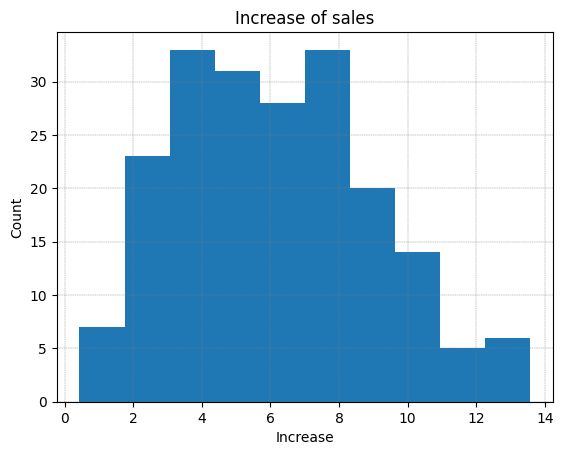

In [6]:
#histogram of increse
#Histogram Node in SPSS

# show the histogram for increase value
plt.hist(data_with_increase["Increase"])
# adds the title
plt.title("Increase of sales")
# adds label to x axis
plt.xlabel('Increase')
# adds label to y axis
plt.ylabel('Count')
# adds grid to the histogram
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.3)
# save as png for dokumentation
plt.savefig('hist_increase_data_understanding.png')

In [160]:
#Plot dependecy of two variables colored by Class
#Plot Node in SPSS

"""
Function plots the scatter graph for Confection, Drink, Luxury and Meat 
"""
def plot_plot_graph(data, x_axis, y_axis, title, saved_png):
    # create subplots for scatter graph
    fig, ax = plt.subplots()
    # define the colors for groups of data for graph
    colors = {'Confection':'red', 'Drink':'green', 'Luxury':'blue', 'Meat':'yellow'}
    # group the data by Class
    grouped = data.groupby('Class')
    # go through the grouped data in cycle
    for key, group in grouped:
        # plot the graph by keys and map the colors
        group.plot(ax=ax, kind='scatter', x=x_axis, y=y_axis, label=key, color=colors[key])
    # adds the title
    plt.title(title)
    # save as png for dokumentation
    plt.savefig(saved_png)
    # show the graph
    plt.show()

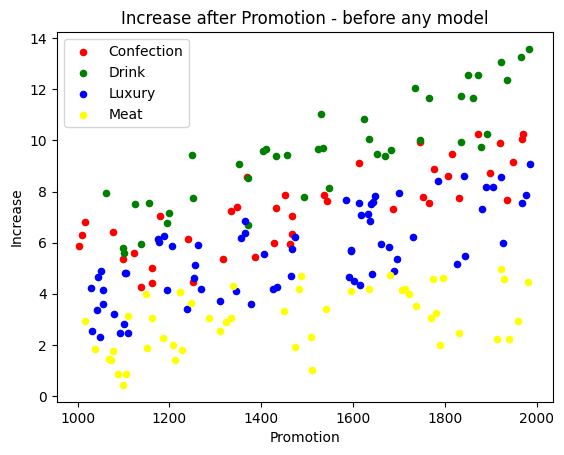

In [161]:
#Plot dependecy of Increase on Promotion colored by Class

# run the plotting scatter graph for Class
plot_plot_graph(data_with_increase, 'Promotion', 'Increase', "Increase after Promotion - before any model", 'increase_after_promotion_data_understanding.png')

In [162]:
#Adds flags
#SetToFlag Node in SPSS

"""
Adds the Class flag to the data
"""
def add_class_flags(data):
    # array for confection
    confection_class_flag_array = []
    # array for drink
    drink_class_flag_array = []
    # array for luxury
    luxury_class_flag_array = []
    # array for meat
    meat_class_flag_array = []

    # copy of dataframe for adding the flags
    data_with_flags = data.copy()
    # go through the dataframe by Class
    for index in range(0, len(data_with_flags["Class"])):
        # ask if the Class is Confection
        if data_with_flags["Class"][index] == "Confection":
            # adds the one to the array for confection
            confection_class_flag_array.append(1.0)
            # adds the zero to the array for drink
            drink_class_flag_array.append(0.0)
            # adds the zero to the array for luxury
            luxury_class_flag_array.append(0.0)
            # adds the zero to the array for meat
            meat_class_flag_array.append(0.0)
        # ask if the Class is Drink
        elif data_with_flags["Class"][index] == "Drink":
            # adds the zero to the array for confection
            confection_class_flag_array.append(0.0)
            # adds the one to the array for drink
            drink_class_flag_array.append(1.0)
            # adds the zero to the array for luxury
            luxury_class_flag_array.append(0.0)
            # adds the zero to the array for meat
            meat_class_flag_array.append(0.0)
        # ask if the Class is Luxury
        elif data_with_flags["Class"][index] == "Luxury":
            # adds the zero to the array for confection
            confection_class_flag_array.append(0.0)
            # adds the zero to the array for drink
            drink_class_flag_array.append(0.0)
            # adds the one to the array for luxury
            luxury_class_flag_array.append(1.0)
            # adds the zero to the array for meat
            meat_class_flag_array.append(0.0)
        # else the Class is meat
        else:
            # adds the zero to the array for confection
            confection_class_flag_array.append(0.0)
            # adds the zero to the array for drink
            drink_class_flag_array.append(0.0)
            # adds the zero to the array for luxury
            luxury_class_flag_array.append(0.0)
            # adds the one to the array for meat
            meat_class_flag_array.append(1.0)

    # adds all flags to the dataframe
    data_with_flags.loc[:, "Confection_Flag"] = confection_class_flag_array
    data_with_flags.loc[:, "Drink_Flag"] = drink_class_flag_array
    data_with_flags.loc[:, "Luxury_Flag"] = luxury_class_flag_array
    data_with_flags.loc[:, "Meat_Flag"] = meat_class_flag_array

    return data_with_flags

In [163]:
#Calls adding flags

# calls the adding flags to the dataframe
data_with_increase_and_flags = add_class_flags(data_with_increase)

In [164]:
#Print dataframe of File with Increase and Flags
#Table Node in SPSS

# print the raw data with increase and flags
print(data_with_increase_and_flags)

          Class    Cost  Promotion  Before   After   Increase  \
0    Confection   23.99       1467  114957  122762   6.357831   
1         Drink   79.29       1745  123378  137097  10.006784   
2        Luxury   81.99       1426  135246  141172   4.197716   
3    Confection   74.18       1098  231389  244456   5.345338   
4    Confection   90.09       1968  235648  261940  10.037413   
..          ...     ...        ...     ...     ...        ...   
195      Luxury   87.95       1206  208121  221053   5.850181   
196      Luxury   95.45       1678  224351  238264   5.839321   
197      Luxury   69.04       1926  264383  281239   5.993479   
198       Drink  104.56       1530  140021  157411  11.047513   
199  Confection   10.88       1162  206186  217102   5.028051   

     Confection_Flag  Drink_Flag  Luxury_Flag  Meat_Flag  
0                1.0         0.0          0.0        0.0  
1                0.0         1.0          0.0        0.0  
2                0.0         0.0          

In [165]:
#Adds Interactions
#Derive Node in SPSS

"""
Adds the interactions = Flag * Promotion
"""
def add_interaction(data):
    # array for confection interaction
    confection_class_interaction_array = []
    # array for drink interaction
    drink_class_interaction_array = []
    # array for luxury interaction
    luxury_class_interaction_array = []
    # array for meat interaction
    meat_class_interaction_array = []

    # copy the dataframe
    data_with_interactions = data.copy()
    # run through the dataframe by Class
    for index in range(0, len(data_with_interactions["Class"])):
        # gets the promotion value
        promotion = data_with_interactions["Promotion"][index]
        # adds the confection interaction to the array
        confection_class_interaction_array.append(data_with_interactions["Confection_Flag"][index] * promotion)
        # adds the drink interaction to the array
        drink_class_interaction_array.append(data_with_interactions["Drink_Flag"][index] * promotion)
        # adds the luxury interaction to the array
        luxury_class_interaction_array.append(data_with_interactions["Luxury_Flag"][index] * promotion)
        # adds the meat interaction to the array
        meat_class_interaction_array.append(data_with_interactions["Meat_Flag"][index] * promotion)

    # adds the interactions to the dataframe
    data_with_interactions.loc[:, "Confection_Interaction"] = confection_class_interaction_array
    data_with_interactions.loc[:, "Drink_Interaction"] = drink_class_interaction_array
    data_with_interactions.loc[:, "Luxury_Interaction"] = luxury_class_interaction_array
    data_with_interactions.loc[:, "Meat_Interaction"] = meat_class_interaction_array

    return  data_with_interactions

In [166]:
#Call adding of interactions

# calls the adding of interaction to the dataframe with raw data, increase and flags
data_with_increase_and_flags_and_interactions = add_interaction(data_with_increase_and_flags)

In [167]:
#Print dataframe of File with Increase, Flags and Interactions
#Table Node in SPSS

# print the dataframe with added increase
print(data_with_increase_and_flags_and_interactions)

          Class    Cost  Promotion  Before   After   Increase  \
0    Confection   23.99       1467  114957  122762   6.357831   
1         Drink   79.29       1745  123378  137097  10.006784   
2        Luxury   81.99       1426  135246  141172   4.197716   
3    Confection   74.18       1098  231389  244456   5.345338   
4    Confection   90.09       1968  235648  261940  10.037413   
..          ...     ...        ...     ...     ...        ...   
195      Luxury   87.95       1206  208121  221053   5.850181   
196      Luxury   95.45       1678  224351  238264   5.839321   
197      Luxury   69.04       1926  264383  281239   5.993479   
198       Drink  104.56       1530  140021  157411  11.047513   
199  Confection   10.88       1162  206186  217102   5.028051   

     Confection_Flag  Drink_Flag  Luxury_Flag  Meat_Flag  \
0                1.0         0.0          0.0        0.0   
1                0.0         1.0          0.0        0.0   
2                0.0         0.0       

In [168]:
#Split to Predictors and Target Value

# define the data which are the predictors
input_var = data_with_increase_and_flags_and_interactions[["Promotion", "Confection_Flag", "Drink_Flag", "Luxury_Flag", "Meat_Flag", "Confection_Interaction", "Drink_Interaction", "Luxury_Interaction", "Meat_Interaction"]]
# define the data which are the target
output_var = data_with_increase_and_flags_and_interactions[["Increase"]]

In [169]:
# Split to Train and Test Data
# Node Partion in SPSS

# split data to the input data for trainning and testing and the target values for trainning and testing values 
x_train, x_test, y_train, y_test = train_test_split(input_var, output_var, test_size=0.5, train_size=0.5)

In [170]:
# Linear Model train a test
# Linear Model Node in SPSS

# trains the linear regression model
linear_model = LinearRegression().fit(x_train, y_train)
# predict the values of increase for testing the model
y_pred = linear_model.predict(x_test)

In [171]:
#[[var],[var],[var],...] -> [var,var,var,...]
"""
Gets the values from inside arrays
"""
def get_predicted_data_without_inside_arrays(y_predicted):
    # array for output
    y_pred_list_from_numpy_without_inline_arrays = []
    # go through the values of array
    for row in y_predicted:
        # throw out the inside arrays and adds the value to the output array
        y_pred_list_from_numpy_without_inline_arrays.append(row[0])
    return y_pred_list_from_numpy_without_inline_arrays

In [172]:
# Statistics Linear Regression
# Analysis Node in SPSS

"""
Prints the analysis
"""
def print_analysis(method, y_test, y_pred, data_pd):
    # print the header of analysis
    print("########################")
    print("####### Analysis #######")
    print("########################")

    # print the used method (Linear Regression or Decision Tree Regression)
    print()
    print(f"Method: {method}")

    # prints the header for Errors
    print()
    print("------- Errors -------")
    # calculate the max error of the model
    max_error = met.max_error(y_test, y_pred)
    # calculate the mean squared error of the model
    mean_squared_error = met.mean_squared_error(y_test, y_pred)
    # calculate the mean absolute error of the model
    mean_absolute_error = met.mean_absolute_error(y_test, y_pred)
    # calculate the mean squared logaritmical error of the model
    mean_squared_log_error = met.mean_squared_log_error(y_test, y_pred)
    # print the errors
    print(f"Max Error: {max_error}")
    print(f"Mean Squared Error: {mean_squared_error}")
    print(f"Mean Absolute Error: {mean_absolute_error}")
    print(f"Mean Squared Logaritmical Error: {mean_squared_log_error}")
    # calculate the root mean squared error of the model
    root_mean_squared_error = met.root_mean_squared_error(y_test, y_pred)
    # calculate the root mean squared logaritmical error of the model
    root_mean_squared_log_error = met.root_mean_squared_log_error(y_test, y_pred)
    # print the errors
    print(f"Root Mean Squared Error: {root_mean_squared_error}")
    print(f"Root Mean Squared Logaritmical Error: {root_mean_squared_log_error}")

    # calculate the mean poisson deviance of the model
    mean_poisson_deviance = met.mean_poisson_deviance(y_test, y_pred)
    # calculate the mean gamma deviance of the model
    mean_gamma_deviance = met.mean_gamma_deviance(y_test, y_pred)
    # calculate the mean tweedie deviance of the model
    mean_tweedie_deviance = met.mean_tweedie_deviance(y_test, y_pred)
    # print the Deviance header
    print()
    print("------- Deviance -------")
    # print the all deviances
    print(f"Mean Poisson Deviance: {mean_poisson_deviance}")
    print(f"Mean Gamma Deviance: {mean_gamma_deviance}")
    print(f"Mean Tweedie Deviance: {mean_tweedie_deviance}")

    # copy the predicted values (Increase) for correlation
    y_to_corr = y_test.copy()
    # ask if the method is linear regression
    if method == "Linear Regression":
        # throw out the inside arrays from the array
        y_pred_list_from_numpy_without_inline_arrays = get_predicted_data_without_inside_arrays(y_pred)
        # adds the predicted increase
        y_to_corr["Increase_Predicted"] = y_pred_list_from_numpy_without_inline_arrays
    # else the method is decision tree regression
    else:
        # adds the predicted increase
        y_to_corr["Increase_Predicted"] = y_pred

    # print the Correlation header
    print()
    print("------- Correlation -------")
    # print the correlation and calculate it
    print(y_to_corr.corr())

    # print the Occurrences header
    print()
    print("------- Occurrences -------")
    # print number of original occurences
    print(f"Occurrences: {len(data_pd)}")

In [173]:
#Print Analysis for Linear Regression

# calls the printting of analysis of linear regression
print_analysis("Linear Regression", y_test, y_pred, data_with_increase_and_flags_and_interactions)

########################
####### Analysis #######
########################

Method: Linear Regression

------- Errors -------
Max Error: 2.4481169747900022
Mean Squared Error: 1.3754790688618899
Mean Absolute Error: 0.989309790834766
Mean Squared Logaritmical Error: 0.050374740922228725
Root Mean Squared Error: 1.172808197814924
Root Mean Squared Logaritmical Error: 0.2244431797186734

------- Deviance -------
Mean Poisson Deviance: 0.3009455396839711
Mean Gamma Deviance: 0.08636712496347186
Mean Tweedie Deviance: 1.3754790688618899

------- Correlation -------
                    Increase  Increase_Predicted
Increase            1.000000            0.903601
Increase_Predicted  0.903601            1.000000

------- Occurrences -------
Occurrences: 200


In [174]:
#Transform Class Flag to Class

"""
Transform the flags to the original names of flags
"""
def transform_flag_to_name(data, class_array, flag, name):
    # runs through the defined flag
    for index, row in enumerate(data[flag]):
        # adds in the index of array flag string if flag is one
        if(row == 1):
            class_array[index] = name
    return class_array

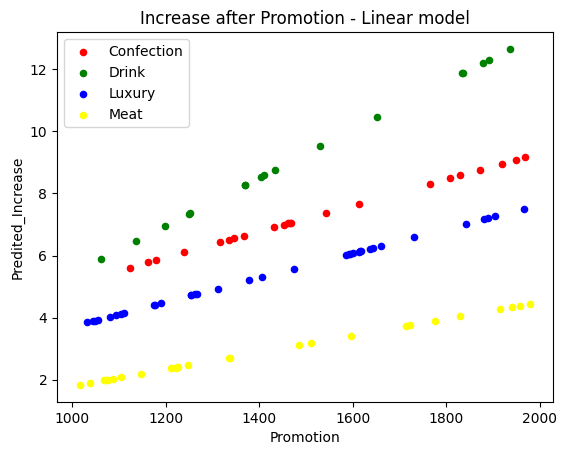

In [175]:
#Plot dependecy of Promotion and Predicted Increase colored by Class (Linear Regresion)
#Adds Class to dataframe

# copy the dataframe with input data for model
x_test_plus_predicted_increase_linear_model = x_test.copy()
# array for predicted increase
class_array_predicted_linear = [""] * len(x_test_plus_predicted_increase_linear_model)

# tranform the the name of confection flag to confection string and add to the array on the index
class_array_predicted_linear = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_linear, "Confection_Flag", "Confection")
# tranform the the name of drink flag to drink string and add to the array on the index
class_array_predicted_linear = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_linear, "Drink_Flag", "Drink")
# tranform the the name of luxury flag to luxury string and add to the array on the index
class_array_predicted_linear = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_linear, "Luxury_Flag", "Luxury")
# tranform the the name of meat flag to meat string and add to the array on the index
class_array_predicted_linear = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_linear, "Meat_Flag", "Meat")

# adds the predicted increase a class to the dataframe
x_test_plus_predicted_increase_linear_model["Predited_Increase"] = get_predicted_data_without_inside_arrays(y_pred)
x_test_plus_predicted_increase_linear_model["Class"] = class_array_predicted_linear

# call the plotting scatter graph for linear regression model
plot_plot_graph(x_test_plus_predicted_increase_linear_model, "Promotion", "Predited_Increase", "Increase after Promotion - Linear model", "increase_after_promotion_linear_model_modeling.png")

In [176]:
# DesisionTreeRegressor Model train a test
# C&R Tree Model Node in SPSS

# train the decision tree regression model
decision_tree_model = DecisionTreeRegressor().fit(x_train, y_train)
# predict the increase values for testong the model 
y_pred_dec_tree = decision_tree_model.predict(x_test)

In [177]:
#Print Analysis for Decision Tree Regression

# call the printing analysis for decision tree regression model
print_analysis("Decision Tree Regression", y_test, y_pred_dec_tree, data_with_increase_and_flags_and_interactions)

########################
####### Analysis #######
########################

Method: Decision Tree Regression

------- Errors -------
Max Error: 3.1514231980510257
Mean Squared Error: 2.6144819470379828
Mean Absolute Error: 1.3383981475234719
Mean Squared Logaritmical Error: 0.09852603827475939
Root Mean Squared Error: 1.6169359749346857
Root Mean Squared Logaritmical Error: 0.31388857620939214

------- Deviance -------
Mean Poisson Deviance: 0.6334950174158313
Mean Gamma Deviance: 0.31289484474495277
Mean Tweedie Deviance: 2.6144819470379828

------- Correlation -------
                    Increase  Increase_Predicted
Increase            1.000000            0.841955
Increase_Predicted  0.841955            1.000000

------- Occurrences -------
Occurrences: 200


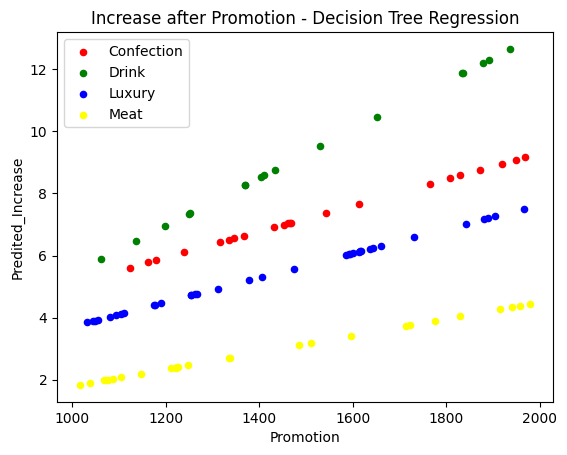

In [178]:
#Plot dependecy of Promotion and Predicted Increase colored by Class (Decision Tree Regresion)
#Adds Class to dataframe

# create the copy of the data for testing
x_test_plus_predicted_increase_dec_tree_model = x_test.copy()
# array for class strings
class_array_predicted_dec_tree = [""] * len(x_test_plus_predicted_increase_dec_tree_model)

# tranform the the name of confection flag to confection string and add to the array on the index
class_array_predicted_dec_tree = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_dec_tree, "Confection_Flag", "Confection")
# tranform the the name of drink flag to drink string and add to the array on the index
class_array_predicted_dec_tree = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_dec_tree, "Drink_Flag", "Drink")
# tranform the the name of luxury flag to luxury string and add to the array on the index
class_array_predicted_dec_tree = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_dec_tree, "Luxury_Flag", "Luxury")
# tranform the the name of meat flag to meat string and add to the array on the index
class_array_predicted_dec_tree = transform_flag_to_name(x_test_plus_predicted_increase_linear_model, class_array_predicted_dec_tree, "Meat_Flag", "Meat")
# add the predicted increase and class string for flags
x_test_plus_predicted_increase_dec_tree_model["Predited_Increase"] = y_pred_dec_tree
x_test_plus_predicted_increase_linear_model["Class"] = class_array_predicted_dec_tree

# call the plot of scatter graph for Class for decision tree regression
plot_plot_graph(x_test_plus_predicted_increase_linear_model, "Promotion", "Predited_Increase", "Increase after Promotion - Decision Tree Regression", "increase_after_promotion_decision_tree_model_modeling.png")

In [179]:
#Generate data for evaluation
#User Input in SPSS

# array for Class strings for evaluate
class_evaluate_array_input = []
# array for Promotion value for evaluate
promotion_evaluate_array_input = []
# array for Before value for evaluate
before_evaluate_array_input = []

# generate the data for evaluating
for class_v in ["Confection", "Drink", "Luxury",  "Meat"]:
    for promotion_v in range(1000, 2000, 100):
        for before_v in range(10000, 30000, 1000):
            class_evaluate_array_input.append(class_v)
            promotion_evaluate_array_input.append(promotion_v)
            before_evaluate_array_input.append(before_v)

In [180]:
#Get every 100 piece
#Sample Node in SPSS

# array for taked away values of Class
class_evaluate_array = []
# array for taked away values of Promotion
promotion_evaluate_array = []
# array for taked away values of Before
before_evaluate_array = []

# cycle which takes get every houndred index of evaluation data
for index in range(0, len(class_evaluate_array_input), 100):
    class_evaluate_array.append(class_evaluate_array_input[index])
    promotion_evaluate_array.append(promotion_evaluate_array_input[index])
    before_evaluate_array.append(before_evaluate_array_input[index])

In [181]:
# Generate the dataframe for evaluating

# pandas dataframe of Class, Promotion and Before values
evaluation_data_in_dataframe = pd.DataFrame({"Class": class_evaluate_array, "Promotion": promotion_evaluate_array, "Before": before_evaluate_array})
# adds the flags for Class
data_for_evaluation_with_flags = add_class_flags(evaluation_data_in_dataframe)

# print the dataframe for evaluating with flags
print(data_for_evaluation_with_flags)

        Class  Promotion  Before  Confection_Flag  Drink_Flag  Luxury_Flag  \
0  Confection       1000   10000              1.0         0.0          0.0   
1  Confection       1500   10000              1.0         0.0          0.0   
2       Drink       1000   10000              0.0         1.0          0.0   
3       Drink       1500   10000              0.0         1.0          0.0   
4      Luxury       1000   10000              0.0         0.0          1.0   
5      Luxury       1500   10000              0.0         0.0          1.0   
6        Meat       1000   10000              0.0         0.0          0.0   
7        Meat       1500   10000              0.0         0.0          0.0   

   Meat_Flag  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  
6        1.0  
7        1.0  


In [182]:
#Call adding of interactions

# call the adding of interaction
data_for_evaluation_with_flags_and_interactions = add_interaction(data_for_evaluation_with_flags)
# print the dataframe for evaluating with flags and interaction
print(data_for_evaluation_with_flags_and_interactions)

        Class  Promotion  Before  Confection_Flag  Drink_Flag  Luxury_Flag  \
0  Confection       1000   10000              1.0         0.0          0.0   
1  Confection       1500   10000              1.0         0.0          0.0   
2       Drink       1000   10000              0.0         1.0          0.0   
3       Drink       1500   10000              0.0         1.0          0.0   
4      Luxury       1000   10000              0.0         0.0          1.0   
5      Luxury       1500   10000              0.0         0.0          1.0   
6        Meat       1000   10000              0.0         0.0          0.0   
7        Meat       1500   10000              0.0         0.0          0.0   

   Meat_Flag  Confection_Interaction  Drink_Interaction  Luxury_Interaction  \
0        0.0                  1000.0                0.0                 0.0   
1        0.0                  1500.0                0.0                 0.0   
2        0.0                     0.0             1000.0     

In [183]:
#Evaluate via model

# input variables for evaluating the linear model
input_var_evaluation = data_for_evaluation_with_flags_and_interactions[["Promotion", "Confection_Flag", "Drink_Flag", "Luxury_Flag", "Meat_Flag", "Confection_Interaction", "Drink_Interaction", "Luxury_Interaction", "Meat_Interaction"]]
# predict the increase for evaluating the model
evaluated_values = linear_model.predict(input_var_evaluation)
# throw out the inside arrays from array and keep the values in the array
evaluated_values_without_inside_values = get_predicted_data_without_inside_arrays(evaluated_values)
# print the predicted values of increase
print("Increase values: ", evaluated_values_without_inside_values)

Increase values:  [5.0989281741258905, 7.195538858274457, 5.416461060622812, 9.282761840364083, 3.7185982520647256, 5.679295714715721, 1.7899554661580712, 3.1472902908715614]


In [184]:
#Adds Increse Value to the DataFrame

# copy the dataframe of data for evaluation with flags and interactions
data_for_evaluation_with_flags_interactions_and_predicted_increase = data_for_evaluation_with_flags_and_interactions.copy()
# add the predicted increase values
data_for_evaluation_with_flags_interactions_and_predicted_increase["Predicted_Increase"] = evaluated_values_without_inside_values
# print the dataframe with flags, interactions and predited increase
print(data_for_evaluation_with_flags_interactions_and_predicted_increase)

        Class  Promotion  Before  Confection_Flag  Drink_Flag  Luxury_Flag  \
0  Confection       1000   10000              1.0         0.0          0.0   
1  Confection       1500   10000              1.0         0.0          0.0   
2       Drink       1000   10000              0.0         1.0          0.0   
3       Drink       1500   10000              0.0         1.0          0.0   
4      Luxury       1000   10000              0.0         0.0          1.0   
5      Luxury       1500   10000              0.0         0.0          1.0   
6        Meat       1000   10000              0.0         0.0          0.0   
7        Meat       1500   10000              0.0         0.0          0.0   

   Meat_Flag  Confection_Interaction  Drink_Interaction  Luxury_Interaction  \
0        0.0                  1000.0                0.0                 0.0   
1        0.0                  1500.0                0.0                 0.0   
2        0.0                     0.0             1000.0     

In [185]:
# Adds After Variable to the Dataframe
# Derive Node in SPSS

# array for after value caculated from predicted increase and before value
after_var_evaluated_array = []

# go through the dataframe with flags, interactions and predicted increase
for index in range(len(data_for_evaluation_with_flags_interactions_and_predicted_increase)):
    # get the before value
    before_val = data_for_evaluation_with_flags_interactions_and_predicted_increase["Before"][index]
    # get the predicted increase value
    increase_val = data_for_evaluation_with_flags_interactions_and_predicted_increase["Predicted_Increase"][index]
    # calculate the after value
    after_val = before_val + (before_val * increase_val/100)
    # append the calculated after value to the array
    after_var_evaluated_array.append(after_val)

# copy the dataframe with flags, interactions and predicted increase values
data_for_evaluation_with_flags_interactions_predicted_increase_and_after = data_for_evaluation_with_flags_interactions_and_predicted_increase.copy()
# add the predicted after value
data_for_evaluation_with_flags_interactions_predicted_increase_and_after["Predicted_After"] = after_var_evaluated_array
# print the dataframe with flags, interactions,  predicted increase values and after values
print(data_for_evaluation_with_flags_interactions_predicted_increase_and_after)

        Class  Promotion  Before  Confection_Flag  Drink_Flag  Luxury_Flag  \
0  Confection       1000   10000              1.0         0.0          0.0   
1  Confection       1500   10000              1.0         0.0          0.0   
2       Drink       1000   10000              0.0         1.0          0.0   
3       Drink       1500   10000              0.0         1.0          0.0   
4      Luxury       1000   10000              0.0         0.0          1.0   
5      Luxury       1500   10000              0.0         0.0          1.0   
6        Meat       1000   10000              0.0         0.0          0.0   
7        Meat       1500   10000              0.0         0.0          0.0   

   Meat_Flag  Confection_Interaction  Drink_Interaction  Luxury_Interaction  \
0        0.0                  1000.0                0.0                 0.0   
1        0.0                  1500.0                0.0                 0.0   
2        0.0                     0.0             1000.0     

In [186]:
# Filter Interactions and Flags
# Filter Node in SPSS

# get the dataframe with only Class, Promotion, Before, Predicted_Increase  and Predited_After
dataframe_evaluated_filtred = data_for_evaluation_with_flags_interactions_predicted_increase_and_after[["Class", "Promotion", "Before", "Predicted_Increase", "Predicted_After"]]
# print the filtered dataframe
print(dataframe_evaluated_filtred)

        Class  Promotion  Before  Predicted_Increase  Predicted_After
0  Confection       1000   10000            5.098928     10509.892817
1  Confection       1500   10000            7.195539     10719.553886
2       Drink       1000   10000            5.416461     10541.646106
3       Drink       1500   10000            9.282762     10928.276184
4      Luxury       1000   10000            3.718598     10371.859825
5      Luxury       1500   10000            5.679296     10567.929571
6        Meat       1000   10000            1.789955     10178.995547
7        Meat       1500   10000            3.147290     10314.729029
